## Clustering notebook

In [1]:
%matplotlib inline

import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from multiprocessing import Pool
from tqdm import tqdm
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

import k3d

In [2]:
def euclidean_distance(node1, node2):
    """
    Calculate the Euclidean distance between two nodes.

    Parameters:
    node1, node2 (dict): Nodes with 'pos' key containing x, y, z coordinates.

    Returns:
    float: Euclidean distance between node1 and node2.
    """
    pos1 = np.array(node1['pos'])
    pos2 = np.array(node2['pos'])
    return np.linalg.norm(pos1 - pos2)

def add_node_to_graph(graph, node):
    """
    Add a node with attributes to the graph.

    Parameters:
    graph (nx.DiGraph): The graph to which the node will be added.
    node (dict): Node data.
    """
    graph.add_node(
        node['sampleNumber'], 
        pos=(node['x'], node['y'], node['z']), 
        radius=node['radius'], 
        structure_id=node['structureIdentifier'],
        allen_id=node['allenId']
    )

def add_edge_to_graph(graph, parent, child):
    """
    Add an edge between parent and child nodes in the graph, with weight as Euclidean distance.

    Parameters:
    graph (nx.DiGraph): The graph to which the edge will be added.
    parent, child (int): The sampleNumbers of the parent and child nodes.
    """
    graph.add_edge(
        parent, 
        child, 
        weight=euclidean_distance(
            graph.nodes()[parent],
            graph.nodes()[child]
        )
    )


def json_to_digraph(file_path):
    """
    Load a neuronal reconstruction from a JSON file into a NetworkX graph.

    The JSON file contains SWC data with additional brain region information for each node.
    The graph will be a directed tree.

    Parameters:
    file_path (str): Path to the JSON file containing reconstruction data.

    Returns:
    nx.DiGraph: A directed graph representing the neuronal tree.
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
    except IOError as e:
        print(f"Error opening file: {e}")
        return None

    # Certain JSON files may have a single 'neuron' object instead of a 'neurons' array
    neuron_data = data['neuron'] if 'neuron' in data else data['neurons'][0]

    axon_graph, dendrite_graph = nx.DiGraph(), nx.DiGraph()

    for structure, graph in [('dendrite', dendrite_graph), ('axon', axon_graph)]:
        if structure not in neuron_data:
            # Some reconstructions may be missing an axon or dendrite tracing
            print(f"Missing structure {structure} for {file_path}")
            continue
        for node in sorted(neuron_data[structure], key=lambda x: x['sampleNumber']):
            add_node_to_graph(graph, node)
            if node['parentNumber'] != -1:
                add_edge_to_graph(graph, node['parentNumber'], node['sampleNumber'])
                
    if dendrite_graph.nodes() and axon_graph.nodes():
        # Remove duplicate soma node from axon graph
        axon_graph.remove_node(1)  

    # The sampleNumber starts at 1 for both axon and dendrite, so 
    # relabel axon nodes to avoid key collisions when merging the graphs,.
    first_axon_label = max(dendrite_graph.nodes()) + 1 if dendrite_graph.nodes() else 1
    joined_graph = nx.union(
        dendrite_graph, 
        nx.convert_node_labels_to_integers(
            axon_graph, 
            first_label=first_axon_label
        )
    )
    roots = [n for n in joined_graph if joined_graph.in_degree(n) == 0]
    # Link the dendrite to the axon
    if len(roots) == 2:
        add_edge_to_graph(joined_graph, roots[0], roots[1])

    return file_path, joined_graph

# Define a function for filtering the graph based on attribute values
def get_subgraph(G, attribute, values):
    """
    Extract a subgraph from the given graph based on specified attribute values.

    Parameters:
    G (nx.Graph): The original graph from which to extract the subgraph.
    attribute (str): The node attribute used for filtering.
    values (tuple): A tuple of attribute values to include in the subgraph.

    Returns:
    nx.Graph: A subgraph of G containing only nodes with the specified attribute values.
    """
    filtered_nodes = [node for node, attr in G.nodes(data=True) if attr.get(attribute) in values]
    return G.subgraph(filtered_nodes)

def load_graphs(filepaths):
    """
    Load all JSON files in the given directory as graphs using multiprocessing.

    Parameters:
    directory_path (str): Path to the directory containing JSON files.

    Returns:
    list of nx.Graph: A list of graphs loaded from the JSON files.
    """
    # Use multiprocessing pool to load graphs in parallel
    with Pool() as pool:
        # graphs = tqdm(pool.imap(json_to_digraph, filepaths), total=len(filepaths))
        graphs = pool.map(json_to_digraph, filepaths)

    # Organize into dictionary
    return {os.path.splitext(os.path.split(fn)[1])[0] : graph for fn, graph in graphs}


def get_cells_in_regions(manifest_path, acronyms):
    # Load the CSV file
    df = pd.read_csv(manifest_path)

    # If a single acronym is provided, convert it to a list
    if isinstance(acronyms, str):
        acronyms = [acronyms]

    # Filter the dataframe for the specified acronyms and get the filenames
    filtered_df = df[df['soma_acronym'].isin(acronyms)]
    filenames = filtered_df['filename'].tolist()
    filtered_acronyms = filtered_df['soma_acronym'].tolist()

    return filenames, filtered_acronyms

In [3]:
# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}
id_to_parent = ccf_structures.set_index('id')['parent_structure_id'].to_dict()
id_to_parent[None] = None # to account for out of bands points

In [4]:
# Create pathing dictionaries to group children CCF levels
rois = ["CB","MY","P","MB","TH","HY","CNU","CTXsp","HPF","OLF","Isocortex","fiber tracts","VS","grv","retina"] # remove "fiber tracts","VS","grv","retina" later
roiIDs = [acronym_to_id[roi] for roi in rois]
# Get the pathing for each leaf node, find which roi each belongs to
id_to_path = ccf_structures.set_index("id")["structure_id_path"].to_dict()
# Create a new dictionary corresponding each CCF copartment to matching ROI
# id_to_roi = {}
id_to_roi = defaultdict(lambda: np.nan)
# For each CCF compartment, break down path and find matching ROI
for key, val in id_to_path.items():
    # Break down path 
    pathList = [int(struct) for struct in val.split("/") if struct]
    # Find matching ROI (should be empty, or a single element)
    roiList = [id for id in roiIDs if id in pathList]
    if not roiList:
        id_to_roi[key] = np.nan
    else:
        id_to_roi[key] = roiList[0]

# To check which values are uanccounted for
# [id_to_acronym[struct] for struct in [key for key, val in id_to_roi.items() if np.isnan(val)]]

In [5]:
# Assemble list of LC neurons and their genotypes
genotypeDict = {}
folderPath = Path("../data/")
filePaths = []
for folder in os.listdir(folderPath):
    dataPath = folderPath / folder / "Complete_annotated"
    if "685222_12_5_24" in str(dataPath):
        print("Skipping " + str(dataPath) + " due to duplicates.")
        continue
    if os.path.exists(dataPath):
        filePaths.append([os.path.join(dataPath,fn) for fn in os.listdir(dataPath) if fn.endswith(".json")])
        subjectPath = dataPath.parent / "subject.json"
        with open(subjectPath) as f:
            subjectJSON = json.load(f)
        genotypeDict[subjectJSON["subject_id"]] = subjectJSON["genotype"]
# filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]

filePaths = [file for files in filePaths for file in files]

Skipping ../data/685222_12_5_24/Complete_annotated due to duplicates.


In [6]:
# Load neurons
graphs = load_graphs(filePaths)

Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for ../data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for ../data/648434_12_5_24/Complete_annotated/N024-648434-SS.json


In [7]:
# Assemble neuron information into dicts, and then dataframe
i = 0
datasetDicts = {}
for key, val in graphs.items():
    neuronID, sample, annotator = key.split("-")
    try:
        soma = [node for node in val.nodes() if val.nodes[node]["structure_id"] == 1] # Get soma nodes
        assert len(soma) == 1
        genotype = genotypeDict[sample]
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception as e:
        print(f"Error finding structures for: {key}, dropping from dataframe")
        continue
    neuronDict = {"Graph":key, "ID":neuronID, "Sample":sample, "Annotator":annotator, "Genotype":genotype, "somaAP":x, "somaDV":y, "somaML":z}
    datasetDicts[i] = neuronDict
    i = i + 1

dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")

Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [8]:
# Reflect graphs so all neuron somas are on the left hemisphere
mlMidline = 5700
mlReflection = mlMidline*2

# Add column for original soma side
dataDF["somaOnRight"] = dataDF["somaML"] > mlMidline

# Reflect rightside graphs across midline
for index, row in dataDF.iterrows():
    # Grab neurons with somas on right
    if row["somaOnRight"]:
        graph = graphs[row["Graph"]]
        # Update soma position in dataframe
        dataDF.loc[index,"somaML"] = mlReflection - dataDF.loc[index,"somaML"]
        # Reflect every node's position along ML axis
        for node in graph.nodes:
            graph.nodes[node]["pos"] = (graph.nodes[node]["pos"][0], graph.nodes[node]["pos"][1], mlReflection - graph.nodes[node]["pos"][2])

In [9]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index).reset_index()

In [10]:
dataDF

,index,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight
0,0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.6760,4571.1625,4612.8491,False
1,1,N004-685221-BP,N004,685221,BP,Dbh-Cre-KI/wt,10380.2200,4090.0237,4729.5434,True
2,2,N003-685221-HS,N003,685221,HS,Dbh-Cre-KI/wt,10481.6138,4402.5699,4750.0097,True
3,3,N007-685221-BP,N007,685221,BP,Dbh-Cre-KI/wt,10593.5709,4555.7298,4537.9699,True
4,4,N005-685221-JN,N005,685221,JN,Dbh-Cre-KI/wt,10327.1596,4178.1452,4807.0124,True
...,...,...,...,...,...,...,...,...,...,...
103,108,N006-648434-JN,N006,648434,JN,Dbh-Cre-KI/wt,9709.7926,5022.2970,3873.3075,True
104,109,N026-648434-PG,N026,648434,PG,Dbh-Cre-KI/wt,9805.1909,5907.0996,4330.8163,False
105,110,N012-648434-JN,N012,648434,JN,Dbh-Cre-KI/wt,9697.7129,4986.8796,4210.2224,True
106,111,N021-648434-PG,N021,648434,PG,Dbh-Cre-KI/wt,9981.7118,3798.5471,4966.5825,False


## Additional features

### Add fraction of contralateral nodes
Perhaps later should be tweaked to be fractional axonal length. Should load the dataframe in a smarter way as well.

In [62]:
fractionContra = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    contraNodes = [graph.nodes[node]["pos"][2] > mlMidline for node in graph.nodes() if graph.nodes[node]["structure_id"] == 2]
    fractionContra[name] = np.sum(contraNodes) / len(contraNodes)
dataDF = dataDF.merge(pd.DataFrame.from_dict(fractionContra, orient = "index", columns = ["fractionContra"]),left_on="Graph", right_index=True)

### Soma position outliers

In [12]:
# Check outliers for various features
checkValues = ["somaAP","somaML","somaDV"]

# For each feature, calculate outliers
for feature in checkValues:
    q1 = dataDF[feature].quantile(0.25)
    q3 = dataDF[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    dataDF[f"{feature} Outlier"] = (dataDF[feature] < lower_bound) | (dataDF[feature] > upper_bound)

dataDF["soma Outlier"] = np.any(dataDF[[f"{feature} Outlier" for feature in checkValues]], axis = 1)

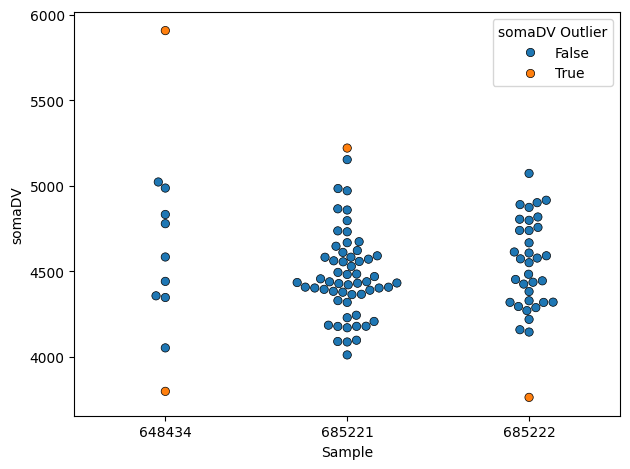

In [13]:
# Plot data highlighting outliers for that feature
feature = "somaDV"

# Plot the data
sns.swarmplot(dataDF, x='Sample', y=feature, edgecolor = 'k', linewidth = .5, hue = f"{feature} Outlier", size = 6)
plt.tight_layout() 
plt.savefig(f"../results/{feature} outliers.svg",dpi=300)

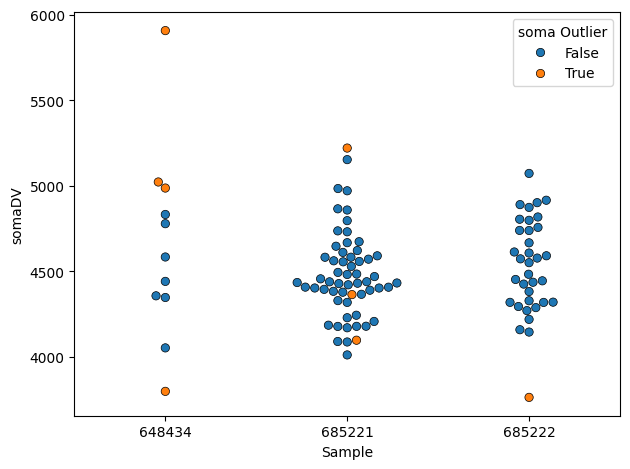

In [14]:
# Plot any outliers

# Plot the data
sns.swarmplot(dataDF, x='Sample', y=feature, edgecolor = 'k', linewidth = .5, hue = "soma Outlier", size = 6)
plt.tight_layout() 
# plt.savefig(f"../results/{feature} outliers.svg",dpi=300)

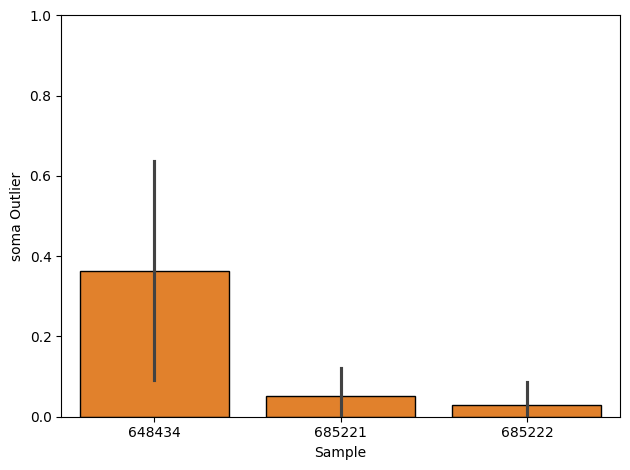

In [15]:
sns.barplot(dataDF, x = "Sample", y = "soma Outlier", edgecolor = 'k', linewidth = 1, color = "tab:orange")
plt.ylim([0, 1])
plt.tight_layout() 
plt.savefig(f"../results/Sample fractional outliers.svg",dpi=300)

## New analyses

In [11]:
def count_preceding_branches(graph, root):
    # Identify branch points (degree > 2)
    branch_points = {node for node, degree in graph.degree() if degree > 2}
    
    # Dictionary to store the count of branches for each node
    branch_counts = {node: 0 for node in graph.nodes}
    
    # BFS to traverse the graph and count branches
    queue = [(root, 0)]  # (current node, branch count)
    visited = set()
    
    while queue:
        node, branch_count = queue.pop(0)
        
        if node in visited:
            continue
        visited.add(node)
        
        # Update branch count for the current node
        branch_counts[node] = branch_count
        
        # If current node is a branch, increment the count for the neighbors
        new_branch_count = branch_count + 1 if node in branch_points else branch_count
        
        # Explore neighbors
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                queue.append((neighbor, new_branch_count))
    
    return branch_counts

In [12]:
graph = graphs[dataDF["Graph"][35]]
branch_counts = count_preceding_branches(graph,1)
branch_points = [node for node, degree in graph.degree() if (degree > 2) & (graph.nodes[node]["structure_id"] == 2)]

In [13]:
branchDict = {}
for name in dataDF["Graph"]:
    # Get each graph, find branch points
    graph = graphs[name]
    branch_points = [node for node, degree in graph.degree() if (degree > 2) & (graph.nodes[node]["structure_id"] == 2)]
    # branchDict[name] = [id_to_acronym[graph.nodes[node]["allen_id"]] for node in branch_points]
    branchDict[name] = {node: id_to_acronym[graph.nodes[node]["allen_id"]] for node in branch_points}
    # branchDict[name] = {node: id_to_acronym[id_to_roi[graph.nodes[node]["allen_id"]]] for node in branch_points}

In [20]:
chooseGraph = 6
graph = graphs[dataDF["Graph"][chooseGraph]]
branch_counts = count_preceding_branches(graph,1)

In [21]:
{branch_counts[node] : branchDict[dataDF["Graph"][chooseGraph]][node] for node in branchDict[dataDF["Graph"][chooseGraph]].keys() if branch_counts[node] < 5}

{1: 'fiber tracts', 2: 'fiber tracts', 3: 'MB', 4: 'MB'}

In [24]:
[branchDict[dataDF["Graph"][chooseGraph]][node] for node in branchDict[dataDF["Graph"][chooseGraph]].keys() if branch_counts[node] == 2]

['P', 'fiber tracts']

In [60]:
branchLevel = 2
branchLocations = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    branch_counts = count_preceding_branches(graph,1)
    branchLocations[name] = [branchDict[name][node] for node in branchDict[name].keys() if branch_counts[node] == branchLevel]

# branchLocations = [x for xs in branchLocations for x in xs]

In [58]:
branchLevel

1

In [56]:
branchLevel = 1
branchLocations = []
for name in dataDF["Graph"]:
    graph = graphs[name]
    branch_counts = count_preceding_branches(graph,1)
    branchLocations.append([branchDict[name][node] for node in branchDict[name].keys() if branch_counts[node] == branchLevel])

branchLocations = [x for xs in branchLocations for x in xs]

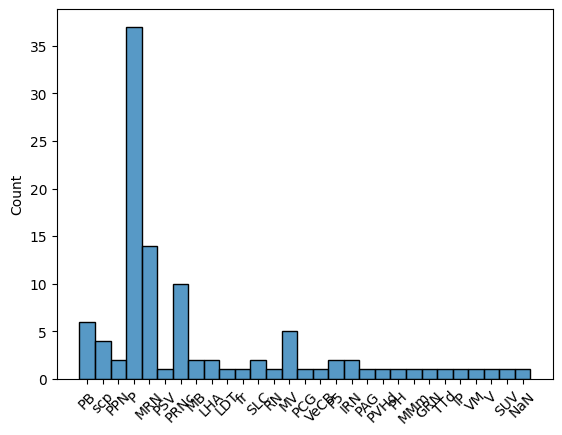

In [57]:
sns.histplot(branchLocations, edgecolor = 'k')
plt.xticks(rotation=45);

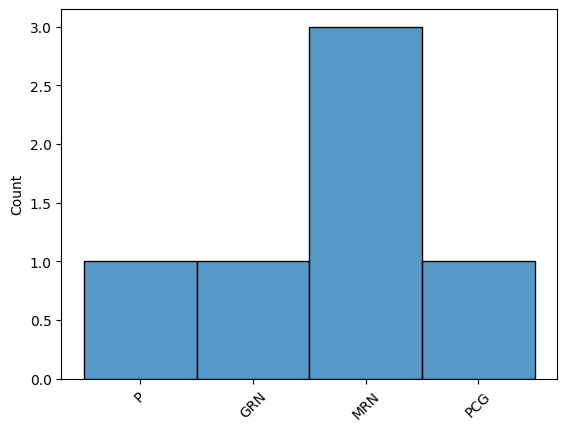

In [77]:

plotGraphs = dataDF["Graph"][dataDF["fractionContra"]>.8].values
plotDict = {key: branchLocations[key] for key in plotGraphs if key in branchLocations}
plotBranches = [x for xs in plotDict.values() for x in xs]
sns.histplot(plotBranches, edgecolor = 'k')
plt.xticks(rotation=45);

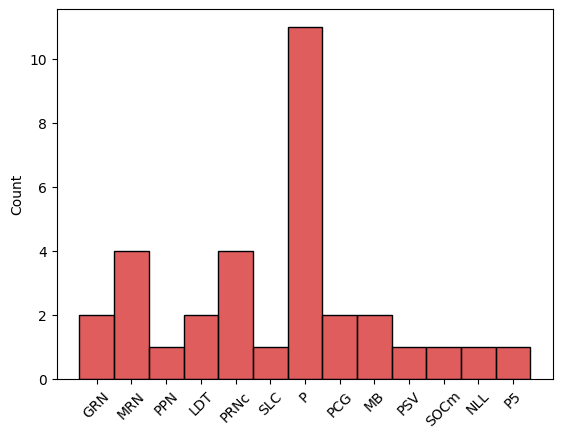

In [86]:
# plotGraphs = dataDF["Graph"][dataDF["fractionContra"]<.8].values
plotGraphs = ctxAndSc
plotDict = {key: branchLocations[key] for key in plotGraphs if key in branchLocations}
plotBranches = [x for xs in plotDict.values() for x in xs]
sns.histplot(plotBranches, color = 'tab:red', edgecolor = 'k')
plt.xticks(rotation=45);

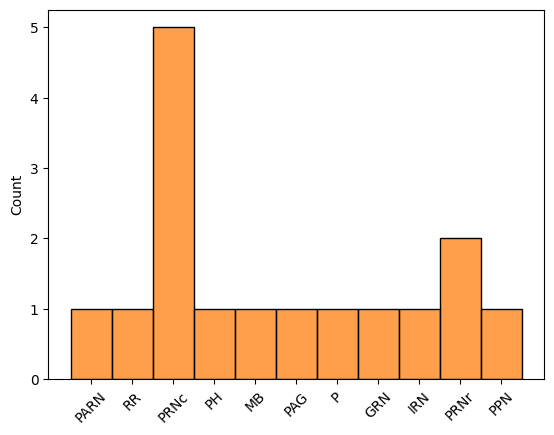

In [88]:
# plotGraphs = dataDF["Graph"][dataDF["fractionContra"]<.8].values
plotGraphs = ibAndSc
plotDict = {key: branchLocations[key] for key in plotGraphs if key in branchLocations}
plotBranches = [x for xs in plotDict.values() for x in xs]
sns.histplot(plotBranches, color = 'tab:orange', edgecolor = 'k')
plt.xticks(rotation=45);

In [83]:
ctxAndSc = ['N030-685222-NM',
 'N048-685221-VM',
 'N044-685221-DS',
 'N014-685221-YV',
 'N022-685221-YP',
 'N054-685221-HS',
 'N052-685221-BP',
 'N041-685221-JN',
 'N038-685221-HS',
 'N005-685222-YP',
 'N021-685222-NM',
 'N016-685221-PG',
 'N035-685221-DS',
 'N016-685222-YP',
 'N004-685222-BP',
 'N010-685222-VM']

ibAndSc = ['N001-685221-PG',
 'N043-685221-HD',
 'N006-685222-DS',
 'N007-685222-BP',
 'N026-685222-SA',
 'N051-685221-YP',
 'N066-685221-JN',
 'N039-685222-AK',
 'N056-685221-AK',
 'N042-685221-HD']

In [123]:
# branch_counts

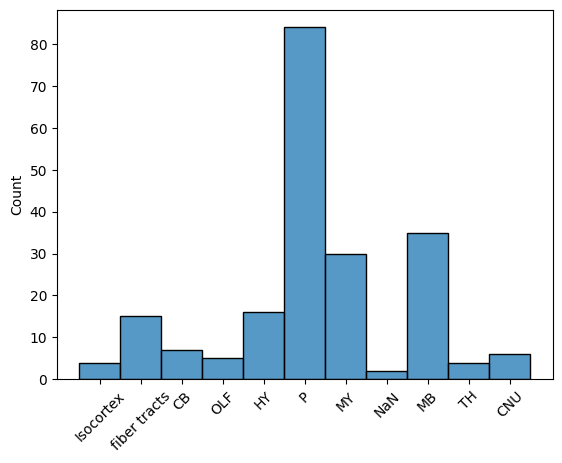

In [121]:
plotList = [branchList[1:3] for branchList in branchDict.values()]
plotList = [x for xs in plotList for x in xs]
sns.histplot(plotList, edgecolor = 'k')
plt.xticks(rotation=45);

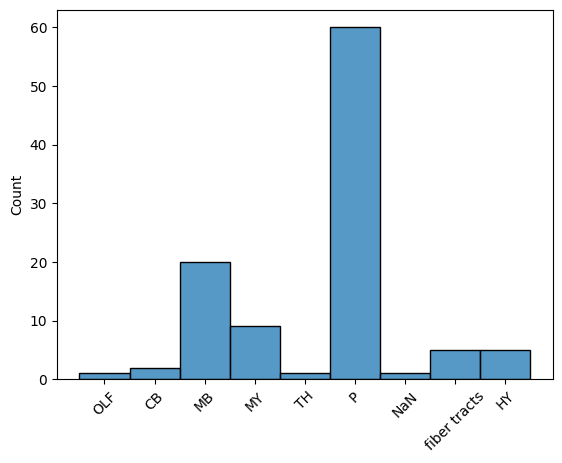

In [109]:
sns.histplot([branchList[0] for branchList in branchDict.values()], edgecolor = 'k')
plt.xticks(rotation=45);

In [11]:
[id_to_acronym[graph.nodes[node]["allen_id"]] for node in branch_points]
# [id_to_acronym[id_to_roi[graph.nodes[node]["allen_id"]]] for node in branch_points]

## Longest path

In [17]:
def get_longest_path(graph):
    longest_path = nx.dag_longest_path(graph, weight='weight')
    longest_path_edges = zip(longest_path, longest_path[1:])
    return longest_path, sum(graph.get_edge_data(*e)['weight'] for e in longest_path_edges)

longest_path, longest_path_len = get_longest_path(graph)
print("longest path from root to any terminal:", longest_path_len, "um") 

longest path from root to any terminal: 9589.568567606011 um


In [18]:
def get_adjusted_region_id(allen_id, ccf_structures, max_ccf_depth):
    """
    Get the adjusted region ID based on the maximum desired CCF depth.

    In some analyses, it may be desirable to limit the granularity of the structure analysis to a certain
    level in the hierarchy. For instance, higher levels (lower depths) correspond to more general
    categories (like 'Cortex'), while lower levels (greater depths) correspond to more specific regions
    (like 'Secondary Motor Area, Layer 5'). Limiting the depth can simplify the analysis by focusing on broader regions
    and avoiding overly detailed subdivisions.

    Parameters:
    allen_id (int): The ID of the structure in the Allen Brain Atlas.
    ccf_structures (DataFrame): A DataFrame containing the mapping of structures to their respective
                                IDs and hierarchical paths in the CCF.
    max_ccf_depth (int): The maximum depth in the CCF hierarchy to consider for the adjustment.

    Returns:
    int: The adjusted region ID if the depth of the structure exceeds the max_ccf_depth, otherwise
         returns the original allen_id.
    """
    if allen_id is None:
        return None
    struct_path = ccf_structures[ccf_structures.id == allen_id].structure_id_path.values[0]
    struct_path = struct_path.strip('/').split('/')
    ccf_depth = len(struct_path) - 1
    if ccf_depth > max_ccf_depth:
        adjustment = max_ccf_depth - ccf_depth
        return int(struct_path[adjustment])
    return allen_id


def trace_longest_path_regions(longest_path, graph, ccf_structures, max_ccf_depth=7):
    """
    Trace the regions along the longest path in a graph, considering the CCF hierarchy.

    Parameters:
    longest_path (list): The longest path in the graph as a list of nodes.
    graph (nx.Graph): The graph representing the neuronal tree.
    ccf_structures (DataFrame): DataFrame containing CCF structure information.
    max_ccf_depth (int): Maximum depth in the CCF hierarchy to consider for regions.

    Returns:
    list: A list of unique region acronyms along the longest path without adjacent duplicates.
    """

    def remove_adjacent_duplicates(seq):
        """Remove adjacent duplicates from a sequence."""
        result = []
        prev = None
        for item in seq:
            if item != prev:
                result.append(item)
                prev = item
        return result

    # Construct the sequence of region acronyms along the longest path
    region_seq = []
    for node in longest_path:
        node_data = graph.nodes().data()[node]
        allen_id = node_data['allen_id']
        adjusted_id = get_adjusted_region_id(allen_id, ccf_structures, max_ccf_depth)
        acronym = ccf_structures[ccf_structures.id == adjusted_id].acronym.values[0]
        region_seq.append(acronym)

    # Remove adjacent duplicates and return the result
    return remove_adjacent_duplicates(region_seq)


In [31]:
graph = graphs[dataDF["Graph"][34]]

In [32]:
longest_path, longest_path_len = get_longest_path(graph)
print("longest path from root to any terminal:", longest_path_len, "um") 

longest path from root to any terminal: 30286.947230341364 um


In [33]:
def plot_path_overlay(graph, path, path_color='red', graph_color='blue'):
    """
    Plot the graph with the longest path highlighted in a different color.

    Parameters:
    graph (nx.Graph): The graph to be visualized.
    path_color (str): Color for the longest path. Default is 'red'.
    graph_color (str): Color for the rest of the graph. Default is 'blue'.
    """

    path_edges = set(zip(path, path[1:]))

    # Draw the graph
    pos = {node: data['pos'][:2] for node, data in graph.nodes(data=True)}
    nx.draw(graph, pos, arrows=False, width=1, node_size=1, with_labels=False, node_color=graph_color, edge_color=graph_color)

    # Draw the longest path on top of the graph
    path_edge_colors = [path_color if (u, v) in path_edges or (v, u) in path_edges else graph_color for u, v in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, nodelist=path, node_color=path_color, node_size=1)
    nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color=path_color, width=1, arrows=False)

    plt.show()


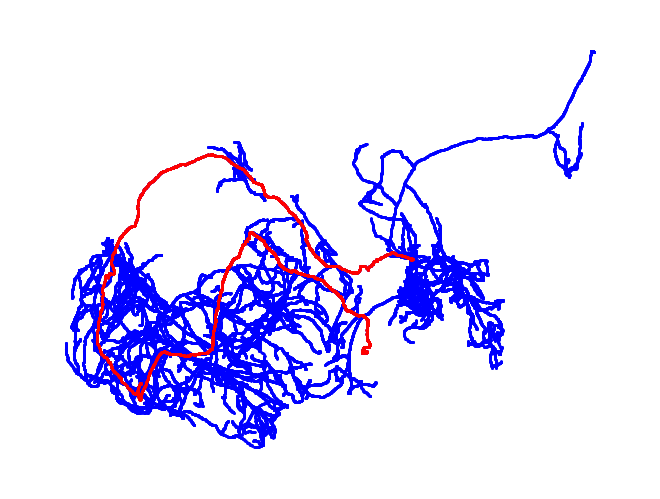

In [34]:
plot_path_overlay(graph, longest_path)

In [35]:
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
ccf_structures.head()

,id,name,acronym,hemisphere_id,parent_structure_id,graph_order,structure_id_path,color_hex_triplet
0,1000,extrapyramidal fiber systems,eps,3,1009.0,1218,/997/1009/1000/,CCCCCC
1,223,Arcuate hypothalamic nucleus,ARH,3,157.0,733,/997/8/343/1129/1097/157/223/,FF5D50
2,12998,"Somatosensory areas, layer 6b",SS6b,3,453.0,36,/997/8/567/688/695/315/453/12998/,188064
3,163,"Agranular insular area, posterior part, layer 2/3",AIp2/3,3,111.0,287,/997/8/567/688/695/315/95/111/163/,219866
4,552,"Pontine reticular nucleus, ventral part",PRNv,3,987.0,914,/997/8/343/1065/771/987/552/,FFBA86


In [36]:
print(" -> ".join(
    trace_longest_path_regions(
        longest_path, 
        graph, 
        ccf_structures,
        max_ccf_depth=6
    )
))

P -> LDT -> P -> MRN -> PPN -> MRN -> scp -> MRN -> RN -> MRN -> INC -> MRN -> MB -> fr -> MB -> PH -> MB -> HY -> MB -> HY -> mtt -> PH -> HY -> AHN -> PeF -> AHN -> HY -> AHN -> HY -> AHN -> HY -> MPO -> AVP -> MPO -> NDB -> MPO -> NDB -> STR -> NDB -> STR -> OLF -> TTd -> DP -> OLF -> ORBm -> PL1 -> ACAd -> MOs -> MOp -> SSp -> SSs -> VISC6a -> SSs -> VISC6a -> VISC5 -> VISC4 -> VISC2/3 -> AIp -> VISC2/3 -> AIp -> VISC1 -> AIp -> VISC1 -> AIp -> VISC1 -> VISC2/3 -> VISC1 -> ECT1 -> TEa1 -> TEa2/3 -> TEa1 -> TEa2/3 -> TEa4 -> TEa5 -> TEa6a -> VISpor -> VISli -> or -> VISli -> or -> VISli -> or -> VISl -> or -> VISl


In [38]:
len(longest_path)

4939

## Plot 3d

In [11]:
def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices


def get_mesh_from_id(allen_id):
    obj_dir = "../data/ccf_2017_obj"
    obj_path = os.path.join(obj_dir, f"{allen_id}.obj")
    return load_obj(obj_path)

def rgb_to_hex(r,g,b):
    # Convert to a hexadecimal string
    hex_color = f'{r:02x}{g:02x}{b:02x}'
    # Convert the hexadecimal string to an integer in base-16
    color_int = int(hex_color, 16)
    return color_int

def plot_graphs(graphs, plot, color=0, opacity = 1, width = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines(g, color, opacity, width)
        plot += g_lines

def graph_to_lines(g, color, opacity = 1, width = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', color=color, width=width, shader='simple', opacity = opacity)
    return g_lines

def plot_ccf_mesh(allen_id, plot, color=0x4d3d3d, opacity=0.1):
    vertices, normals, indices = get_mesh_from_id(allen_id)
    
    plt_tetra = k3d.mesh(
        vertices, 
        indices, 
        normals=normals,
        color=color,
        wireframe=False,
        opacity=opacity
    )

    plot += plt_tetra

# Establish camera views
topdownVertical = [12000, -10000, 5700, 9000, 0, 5700, -1, 0, 0]
topdownHorizontal = [9000, -9000, 5700, 9000, 0, 5700, 0, 0, 1]
topdownAngled = [7000, -12000, 0, 7000, 0, 5700, -.667, -.667, .167]
sideviewHorizontal = [7000, 5000, -8000, 7000, 4500, 5700, 0, -1, 0]

In [12]:
# plotGraph = "N006-685222-DS"
plotGraph = "N053-685221-SP"

plot = k3d.plot()

plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(dataDF["Graph"]):
    if name == plotGraph:
        plot_graphs([graphs[name]],plot, 0, opacity = .8, width = 1)

# Set camera
print(plotGraph)
plot.display()
plot.camera = sideviewHorizontal

N053-685221-SP


Output()

In [21]:

# for i, name in enumerate(dataDF["Graph"]):
#     plot = k3d.plot()
#     plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
#     plot_graphs([graphs[name]],plot, 0, opacity = .8, width = 1)
#     plot.display()
#     plot.camera = sideviewHorizontal
#     with open("../results/"+name+".html", 'w') as f:
#        f.write(plot.get_snapshot())
        
    

In [15]:
graph = graphs["N006-685222-DS"]

In [28]:
graph.nodes[4]

{'pos': (10429.4583, 4722.2205, 4656.8604),
 'radius': 1.0,
 'structure_id': 3,
 'allen_id': 771}

### Plot out of bounds

In [19]:
acronym_to_color = defaultdict(lambda: 0)
acronym_to_color = acronym_to_color | {"NaN" : 16711680}

In [20]:
def plot_graphs_outside(graphs, plot, colorDict, opacity = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines_outside(g, colorDict, opacity)
        plot += g_lines
        
def graph_to_lines_outside(g, colorDict, opacity = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Set color
    g_colors = np.array([colorDict[id_to_acronym[g.nodes[n]['allen_id']]] for n in sorted(g.nodes())],dtype=np.uint32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    print(g_colors[0])
    print(g_colors[1])
    print(g_colors[1000])
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', colors=g_colors, width=1, shader='simple', opacity = opacity)
    return g_lines

In [21]:
r = 0
g = 256
b = 256 
hex_color = f'{r:02x}{g:02x}{b:02x}'
# Convert the hexadecimal string to an integer in base-16
color_int = int(hex_color, 16)
color_int

1048832

In [23]:
# Plot single neuron, coloring out of bounds nodes

plotGraph = "N015-685222-VM"

plot = k3d.plot()

plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(dataDF["Graph"]):
    if name == plotGraph:
        plot_graphs_outside([graphs[name]],plot, acronym_to_color, opacity = .8)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

0
0
0


Output()

In [35]:
compartmentDict = {2 : 16711680, 3: 0, 1:0}
# compartmentDict = defaultdict(lambda: 0)
# compartmentDict = compartmentDict | {3: 16711680}

In [17]:
def plot_graphs_compartment(graphs, plot, colorDict, opacity = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines_compartment(g, colorDict, opacity)
        plot += g_lines
        
def graph_to_lines_compartment(g, colorDict, opacity = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Set color
    g_colors = np.array([colorDict[g.nodes[n]['structure_id']] for n in sorted(g.nodes())],dtype=np.uint32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    print(g_colors[0])
    print(g_colors[1])
    print(g_colors[1000])
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', colors=g_colors, width=1, shader='simple', opacity = opacity)
    return g_lines

In [70]:
# [compartmentDict[graph.nodes[n]['structure_id']] for n in sorted(graph.nodes())]

In [36]:
# Plot single neuron, coloring out of bounds nodes

plotGraph = "N006-685222-DS"

plot = k3d.plot()

plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(dataDF["Graph"]):
    if name == plotGraph:
        plot_graphs_compartment([graphs[name]],plot, compartmentDict, opacity = .8)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

0
0
16711680


Output()

In [74]:
# Plot single neuron, coloring out of bounds nodes

plotGraph = "N015-685222-VM"

plot = k3d.plot()

plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
# plot_ccf_mesh(acronym_to_id['CBX'], plot, color=rgb_to_hex(128,128,0), opacity=0.05)
plot_ccf_mesh(acronym_to_id['arb'], plot, color=rgb_to_hex(0,0,128), opacity=0.05)
for i, name in enumerate(dataDF["Graph"]):
    if name == plotGraph:
        plot_graphs_outside([graphs[name]],plot, acronym_to_color, opacity = .8)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

0
0
0


Output()

In [27]:
with open('../results/outputfile.html', 'w') as f:
   f.write(plot.get_snapshot())